In [1]:
import os
os.getcwd()

'C:\\Users\\nimte\\OneDrive\\Desktop\\real-estate-financial-assistant\\notebooks'

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'classification_training.ipynb',
 'clean_env',
 'features.pkl',
 'regression_training.ipynb',
 'reset.ipynb',
 'scaler.joblib',
 'scaler.pkl']

In [3]:
import numpy, scipy, sklearn

print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)

1.26.4
1.10.1
1.2.2


In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nimte\OneDrive\Desktop\real-estate-financial-assistant\data\raw\bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


STEP 1- EDA

In [5]:
df.shape

(45211, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df["y"].value_counts()

no     39922
yes     5289
Name: y, dtype: int64

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


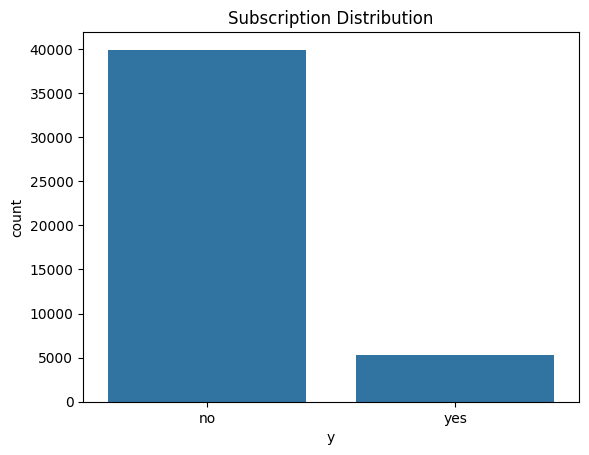

In [10]:
# STEP 2 — Visualize target distribution (EDA)
# Checking class imbalance in the subscription target variable

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="y", data=df)
plt.title("Subscription Distribution")
plt.show()

In [11]:
df["y"].value_counts(normalize=True) * 100

no     88.30152
yes    11.69848
Name: y, dtype: float64

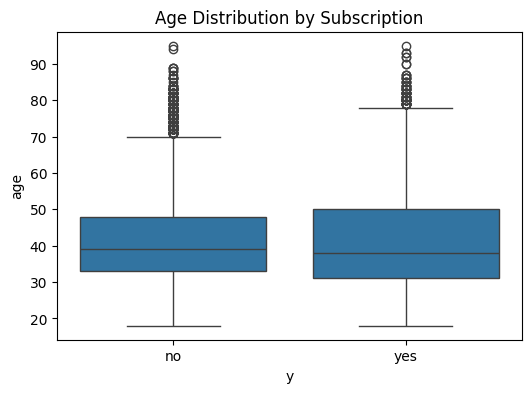

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="y", y="age", data=df)

plt.title("Age Distribution by Subscription")
plt.show()

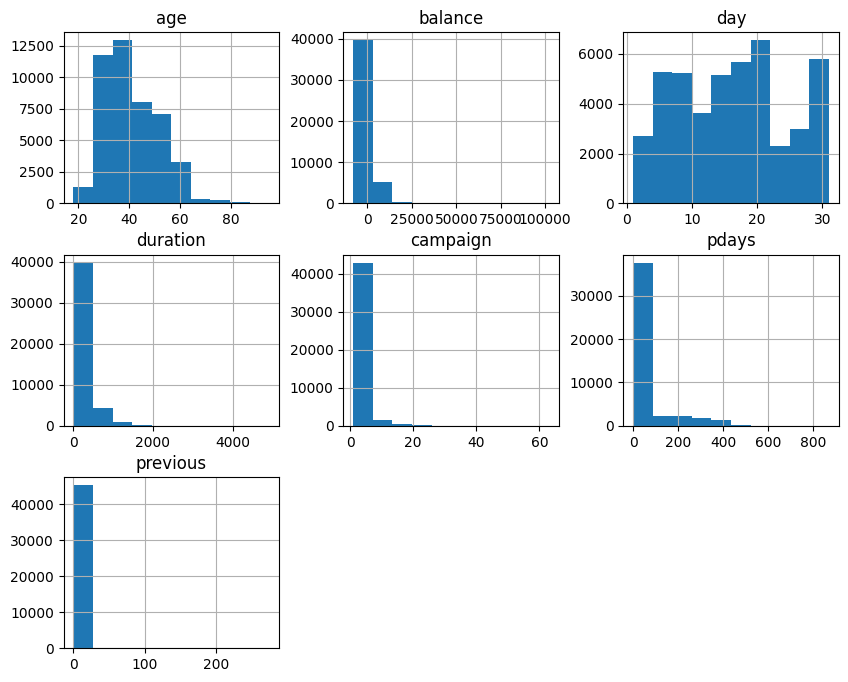

In [13]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

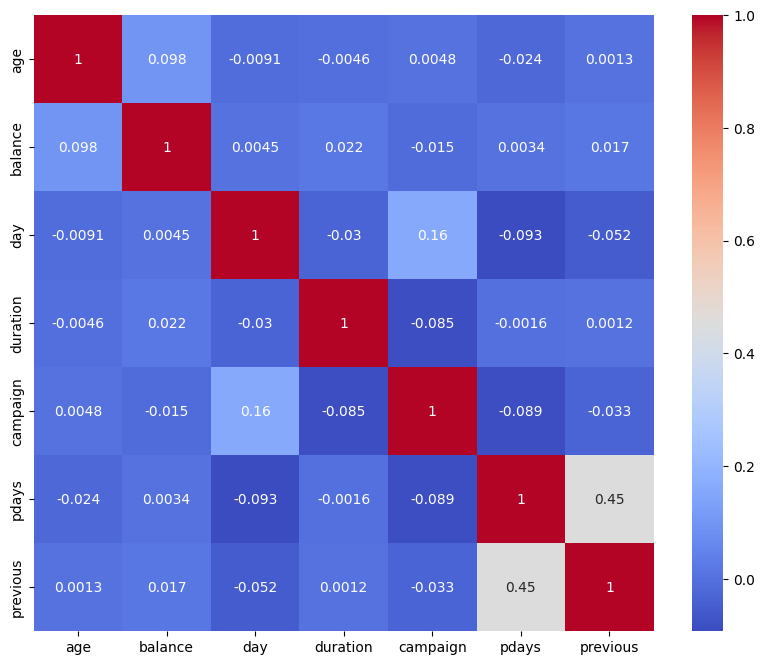

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [15]:
# STEP 3 — Separate target variable before encoding
X = df.drop(["y","duration"], axis=1)
y = df["y"].map({"yes":1,"no":0})

In [16]:
# STEP 4 — Encode categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

In [17]:
# STEP 5 — Use encoded features
X = X_encoded

In [18]:
# STEP 6 – Normalize features using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
#import joblib

#joblib.dump(scaler, "../models/classification/scaler.pkl")

In [20]:
X.dtypes

age                    int64
balance                int64
day                    int64
campaign               int64
pdays                  int64
previous               int64
job_blue-collar        uint8
job_entrepreneur       uint8
job_housemaid          uint8
job_management         uint8
job_retired            uint8
job_self-employed      uint8
job_services           uint8
job_student            uint8
job_technician         uint8
job_unemployed         uint8
job_unknown            uint8
marital_married        uint8
marital_single         uint8
education_secondary    uint8
education_tertiary     uint8
education_unknown      uint8
default_yes            uint8
housing_yes            uint8
loan_yes               uint8
contact_telephone      uint8
contact_unknown        uint8
month_aug              uint8
month_dec              uint8
month_feb              uint8
month_jan              uint8
month_jul              uint8
month_jun              uint8
month_mar              uint8
month_may     

In [21]:
X_scaled.shape

(45211, 41)

In [22]:
# STEP 7 – Feature importance scores using ANOVA

from sklearn.feature_selection import f_classif
import pandas as pd

# Calculate scores
scores, p_values = f_classif(X_scaled, y)

# Create dataframe
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores,
    "P-value": p_values
})

# Sort by importance
feature_scores = feature_scores.sort_values(by="Score", ascending=False)

feature_scores.head(41)

,Feature,Score,P-value
39,poutcome_success,4697.113837,0.000000e+00
40,poutcome_unknown,1297.815887,3.186284e-280
26,contact_unknown,1053.932776,1.456834e-228
23,housing_yes,892.950576,2.621927e-194
33,month_mar,770.566237,3.510013e-168
36,month_oct,759.412860,8.512146e-166
37,month_sep,696.599372,2.355342e-152
4,pdays,490.696563,3.790553e-108
34,month_may,480.019957,7.536665e-106
5,previous,396.443989,7.801830e-88


In [23]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=18)

X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]

selected_features

Index(['campaign', 'pdays', 'previous', 'job_blue-collar', 'job_retired',
       'job_student', 'marital_single', 'education_tertiary', 'housing_yes',
       'loan_yes', 'contact_unknown', 'month_dec', 'month_mar', 'month_may',
       'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

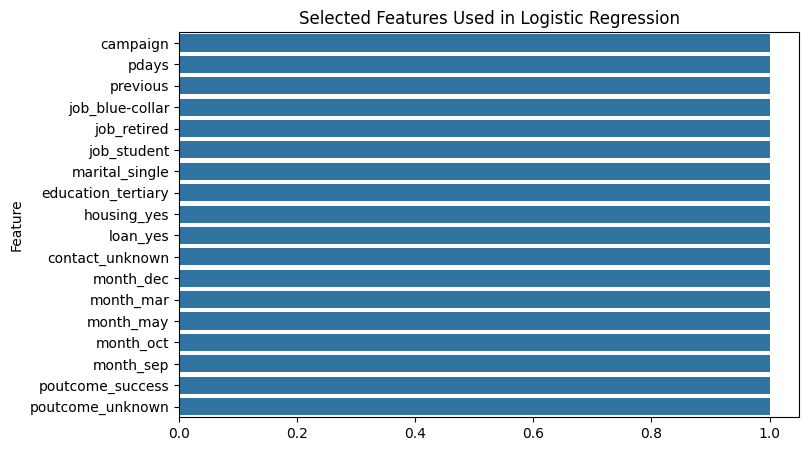

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_df = pd.DataFrame({
    "Feature": selected_features
})

plt.figure(figsize=(8,5))

sns.barplot(
    x=[1]*len(selected_df),
    y="Feature",
    data=selected_df,
    orient="h"
)

plt.title("Selected Features Used in Logistic Regression")
plt.xlabel("")
plt.ylabel("Feature")

plt.show()

In [27]:
# STEP 7 — Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [28]:
import sys
#!{sys.executable} -m pip install imbalanced-learn --no-deps


In [29]:
#!{sys.executable} -m pip install numpy==1.23.5


In [30]:
# STEP 8— Apply Random Oversampling to balance the dataset

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [31]:
# STEP 9 — Check class balance after oversampling

import pandas as pd

pd.Series(y_resampled).value_counts()

0    31970
1    31970
Name: y, dtype: int64

In [32]:
# STEP 10— Train Logistic Regression on oversampled data

from sklearn.linear_model import LogisticRegression

log_model_over = LogisticRegression(max_iter=1000)

log_model_over.fit(X_resampled, y_resampled)

LogisticRegression(max_iter=1000)

In [33]:
# STEP 11 — Predict using oversampled model

y_pred_over = log_model_over.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# TRAIN predictions
y_train_pred = log_model_over.predict(X_train)

# TEST predictions
y_test_pred = log_model_over.predict(X_test)

# TRAIN metrics
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

# TEST metrics
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

# PRINT RESULTS
print("===== TRAIN METRICS =====")
print("Accuracy:", accuracy_train)
print("Precision:", precision_train)
print("Recall:", recall_train)
print("F1 Score:", f1_train)

print("\n===== TEST METRICS =====")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)
print("F1 Score:", f1_test)

===== TRAIN METRICS =====
Accuracy: 0.7413735899137359
Precision: 0.2545229480099029
Recall: 0.6367317770366842
F1 Score: 0.36367346938775513

===== TEST METRICS =====
Accuracy: 0.734269600796196
Precision: 0.25504107542942495
Recall: 0.6260311640696609
F1 Score: 0.3624303528787477


In [35]:
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[5957 1995]
 [ 408  683]]


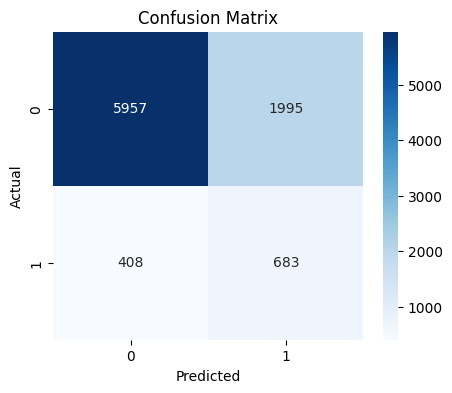

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

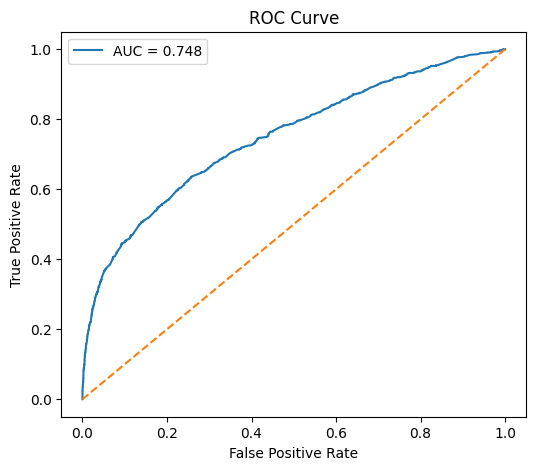

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability predictions
y_prob = log_model_over.predict_proba(X_test)[:,1]

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [38]:
import pandas as pd

pd.DataFrame(selected_features, columns=["Selected Features"])

,Selected Features
0,campaign
1,pdays
2,previous
3,job_blue-collar
4,job_retired
5,job_student
6,marital_single
7,education_tertiary
8,housing_yes
9,loan_yes


In [53]:
import os

os.makedirs("../models/sagemaker/classification", exist_ok=True)

In [54]:
# STEP — Save Logistic Regression model trained with oversampling

import joblib

joblib.dump(log_model_over, "../models/sagemaker/classification/logistic_model.pkl")

['../models/sagemaker/classification/logistic_model.pkl']

In [55]:
import joblib
from sklearn.preprocessing import StandardScaler

# Scaler'ı 18 feature ile yeniden eğit ve kaydet
scaler_final = StandardScaler()
scaler_final.fit(X[selected_features])
joblib.dump(scaler_final, "../models/sagemaker/classification/scaler.pkl")
print("✅ Scaler kaydedildi:", scaler_final.n_features_in_, "feature")

✅ Scaler kaydedildi: 18 feature


Assignment pipeline (classification) 
Completed;

✔ Load dataset
✔ EDA
✔ Encode categorical variables
✔ Normalize numeric variables
✔ Train/Test split
✔ Logistic Regression training
✔ Evaluation metrics
✔ Confusion matrix
✔ Handle class imbalance with oversampling
✔ Save model artifact

In [56]:
# STEP — Load saved classification model

import joblib

model_loaded = joblib.load("../models/sagemaker/classification/logistic_model.pkl")

In [57]:
# STEP — Test model prediction

sample = X_test[0].reshape(1, -1)

prediction = model_loaded.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [58]:
# STEP — Get prediction probability

probability = model_loaded.predict_proba(sample)

print("Prediction Probability:", probability)

Prediction Probability: [[0.80651039 0.19348961]]


In [59]:
!python ../src/classification_model/inference_classification.py

Traceback (most recent call last):
  File "C:\Users\nimte\OneDrive\Desktop\real-estate-financial-assistant\src\classification_model\inference_classification.py", line 5, in <module>
    model = joblib.load(
            ^^^^^^^^^^^^
  File "C:\Users\nimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\numpy_pickle.py", line 735, in load
    with open(filename, "rb") as f:
         ^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\nimte\\OneDrive\\Desktop\\real-estate-financial-assistant\\models\\classification\\logistic_model.pkl'


In [60]:
joblib.dump(selected_features, "../models/sagemaker/classification/features.pkl")

['../models/sagemaker/classification/features.pkl']

In [61]:
FEATURE_PATH = "../models/sagemaker/classification/features.pkl"

selected_features = joblib.load(FEATURE_PATH)

In [62]:
import os
print(os.listdir("../models/sagemaker/classification"))

['.ipynb_checkpoints', 'class-inference.py', 'features.pkl', 'logistic_model.pkl', 'scaler.pkl']


In [63]:
print(selected_features)

Index(['campaign', 'pdays', 'previous', 'job_blue-collar', 'job_retired',
       'job_student', 'marital_single', 'education_tertiary', 'housing_yes',
       'loan_yes', 'contact_unknown', 'month_dec', 'month_mar', 'month_may',
       'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')


In [64]:
len(selected_features)

18

In [65]:
import joblib

scaler = joblib.load("scaler.pkl")
print("Scaler feature count:", scaler.n_features_in_)

feature_order = joblib.load("features.pkl")
print("Features.pkl count:", len(feature_order))
print("Features:", feature_order)

Scaler feature count: 41
Features.pkl count: 18
Features: Index(['campaign', 'pdays', 'previous', 'job_blue-collar', 'job_retired',
       'job_student', 'marital_single', 'education_tertiary', 'housing_yes',
       'loan_yes', 'contact_unknown', 'month_dec', 'month_mar', 'month_may',
       'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')
